In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
import time

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.observables.CometEFT_spectro import CometEFT_SpectroPower
from cloelib.observables.CometVDG_spectro import CometVDG_SpectroPower
from cloelib.summary_statistics.legendre_multipoles import LegendreMultipoles

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

Warning! "libgrid.so" not found, bispectrum binning options will not be available.


/Users/pezzotta/opt/anaconda3/envs/cloelite/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.4.1.post1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
H0 = 67.7
Omega_cdm0 = 0.27
Omega_b0 = 0.049
Omega_k0 = 0.0
w0 = -1.0
wa = 0.0
ns = 0.96
As = 2.1e-9
gamma_MG = 0.545

background_fiducial = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG
)

Omega_cdm0 = 0.28
H0 = 70.0

background = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG
)

In [3]:
RSD_parameters = {
 'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bGam3': 0.323,
 'c0': 30.948, 'c2': 46.233, 'c4': 10.057, 'cnlo': 0.0
}

In [4]:
comet_pk2 = CometEFT_SpectroPower(background=background, RSD_parameters=RSD_parameters, redshift=1.0)                            

In [5]:
noise_syst_parameters = {
 'NP0': 1.056, 'NP20': 0.0, 'NP22': 0.0,
 'fout': 0.0, 'sigmaz': 0.0
}

In [6]:
mps_spectro = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)

In [7]:
k = np.logspace(-3, np.log10(0.3), 101)
mps = mps_spectro.power_multipoles(k=k, ells=[0,2,4])
mps_noAP = mps_spectro.power_multipoles(k=k, ells=[0,2,4], use_AP=False)

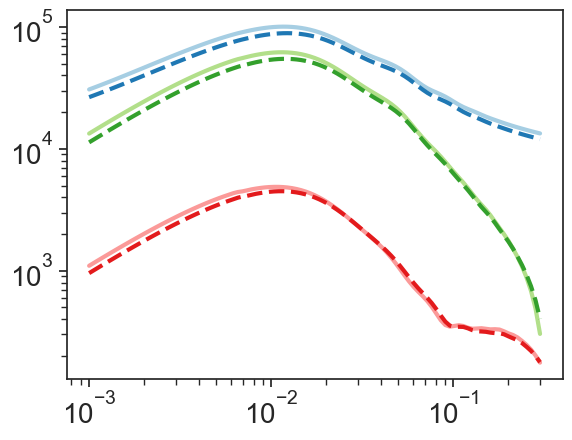

In [8]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_noAP['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_noAP['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_noAP['ell4'], ls='--')

In [9]:
RSD_parameters['b1'] = 2.0
noise_syst_parameters['fout'] = 0.2
noise_syst_parameters['sigmaz'] = 0.002

comet_pk2 = CometEFT_SpectroPower(background=background, RSD_parameters=RSD_parameters, redshift=1.0) 

mps_spectro = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)

mps1 = mps_spectro.power_multipoles(k=k, ells=[0,2,4])

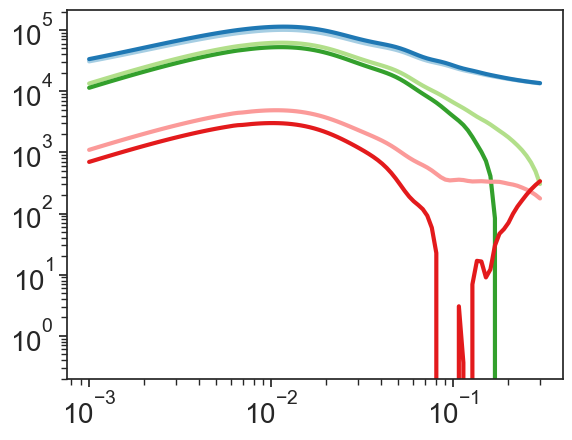

In [10]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps1['ell0'])
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps1['ell2'])
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps1['ell4'])

In [11]:
background1 = CAMBBackground(H0=75.0, 
                             Omega_cdm0=0.25, 
                             Omega_b0=0.049, 
                             w0=-1.5, 
                             wa=0, 
                             Omega_k0 = 0.0, 
                             ns = 0.7, 
                             As = 3.1e-9,
                             gamma_MG = 0.545)

In [12]:
comet_pk2 = CometEFT_SpectroPower(background=background1, RSD_parameters=RSD_parameters, redshift=1.0) 

mps_spectro = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)

mps2 = mps_spectro.power_multipoles(k=k, ells=[0,2,4])

Warning! Leaving emulator rangefor parameter wb
Warning! Leaving emulator rangefor parameter ns


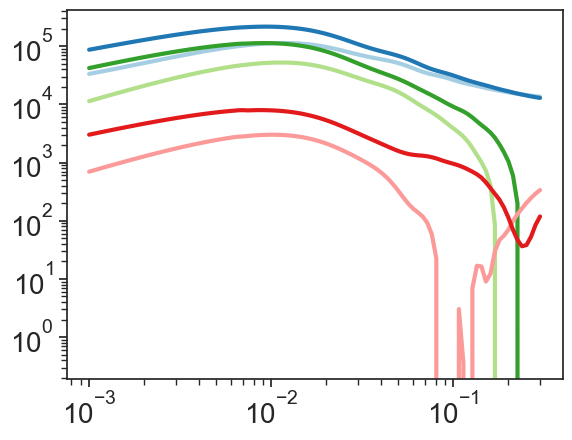

In [13]:
plt.loglog(k, mps1['ell0'])
plt.loglog(k, mps2['ell0'])
plt.loglog(k, mps1['ell2'])
plt.loglog(k, mps2['ell2'])
plt.loglog(k, mps1['ell4'])
plt.loglog(k, mps2['ell4'])

In [14]:
RSD_parameters['avir'] = 3.0

comet_pk2 = CometVDG_SpectroPower(background=background1, RSD_parameters=RSD_parameters, redshift=1.0) 

mps_spectro = LegendreMultipoles(comet_pk2, background_fiducial, noise_syst_parameters, nbar=1e-4)

mps2 = mps_spectro.power_multipoles(k=k, ells=[0,2,4])

Warning! Leaving emulator rangefor parameter wb
Warning! Leaving emulator rangefor parameter ns


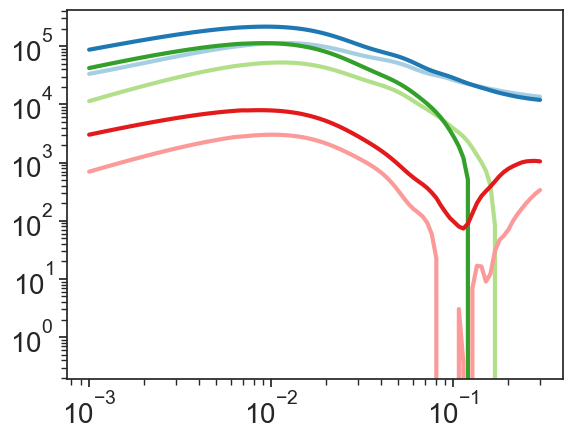

In [15]:
plt.loglog(k, mps1['ell0'])
plt.loglog(k, mps2['ell0'])
plt.loglog(k, mps1['ell2'])
plt.loglog(k, mps2['ell2'])
plt.loglog(k, mps1['ell4'])
plt.loglog(k, mps2['ell4'])